In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms
from PIL import Image

import cv2
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Configuration
DATA_DIR      = "./processed_data"
IMG_SIZE      = 96
BATCH_SIZE    = 64
EPOCHS        = 70
LEARNING_RATE = 0.0005
VAL_SPLIT     = 0.2
MODEL_PATH    = "./model.pth"
PATIENCE      = 10          # early stopping patience

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # 1. sloj: ulaz 96x96
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2), # izlaz: 48x48

            # 2. sloj
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2), # izlaz: 24x24

            # 3. sloj
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # izlaz: 12x12

            # 4. sloj
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2), # izlaz: 6x6

            # 5. sloj - dodatni sloj za bolje učenje
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d(2), # izlaz: 3x3
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   
            nn.Flatten(),               
            nn.Linear(512, 256),       
            nn.ReLU(), 
            nn.Dropout(0.4),            
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [6]:
# Training: augmented
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2),
])

# Validation: NO random ops — this was the original bug
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [7]:
import zipfile, os
zip_path = 'archive.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('./')

In [8]:
# Load the SAME folder twice with DIFFERENT transforms
train_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATA_DIR, transform=val_transform)

train_count = int(len(train_dataset) * (1 - VAL_SPLIT))
val_count   = len(train_dataset) - train_count

# Same seed → identical splits across both dataset objects
generator = torch.Generator().manual_seed(42)
train_data, _ = random_split(train_dataset, [train_count, val_count], generator=generator)

generator = torch.Generator().manual_seed(42)   # reset seed
_, val_data   = random_split(val_dataset,   [train_count, val_count], generator=generator)

class_names = train_dataset.classes
num_class   = len(class_names)
print(f"Classes : {class_names}")
print(f"Train   : {train_count}  |  Val : {val_count}")

Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train   : 39823  |  Val : 9956


In [9]:
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=12, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=12, pin_memory=True)

In [10]:
model     = CNN(num_classes=num_class).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler: halves LR when val loss stalls for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)

# Mixed precision scaler — boosts speed on RTX cards with Tensor Cores
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

c:\Users\jakov\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\jakov\AppData\Local\Temp\ipykernel_3696\3034413831.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


In [11]:
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters    : {total:,}")
    print(f"Trainable parameters: {trainable:,}")

count_parameters(model)

Total parameters    : 1,703,687
Trainable parameters: 1,703,687


In [12]:
def train():
    best_val_acc     = 0.0
    patience_counter = 0
    history          = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        # ── Train ────────────────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        t0 = time.time()

        for images, labels in train_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            # autocast: forward pass in FP16 on GPU, FP32 on CPU
            with torch.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            # scaler handles backprop safely in mixed precision
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)
            correct      += (outputs.detach().argmax(dim=1) == labels).sum().item()
            total        += images.size(0)

        avg_loss = running_loss / total
        avg_acc  = correct / total

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.autocast(device_type=device.type, enabled=torch.cuda.is_available()):
                    outputs = model(images)
                    loss    = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()
                val_total   += images.size(0)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        elapsed   = time.time() - t0

        print(f"EPOCH {epoch:3}/{EPOCHS}  "
              f"train_loss={avg_loss:.3f} train_acc={avg_acc:.3f}  "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}  "
              f"lr={optimizer.param_groups[0]['lr']:.2e}  {elapsed:.1f}s")

        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(avg_acc)
        history["val_acc"].append(val_acc)

        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc     = val_acc
            patience_counter = 0
            torch.save({
                "model_state": model.state_dict(),
                "class_names": class_names,
                "img_size"   : IMG_SIZE,
            }, MODEL_PATH)
            print(f"  ✓ Saved best model  val_acc={best_val_acc:.3f}")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f"Early stopping triggered at epoch {epoch} "
                      f"(no improvement for {PATIENCE} epochs)")
                break

    print("Training complete.")
    return history

In [13]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"],   label="Val Loss")
    ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"],   label="Val Acc")
    ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()

In [14]:
def evaluate(model, loader, class_names):
    """Print classification report + confusion matrix heatmap."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            outputs = model(images)
            preds   = outputs.argmax(dim=1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names,
                cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()

EPOCH   1/70  train_loss=1.581 train_acc=0.364  val_loss=1.358 val_acc=0.467  lr=5.00e-04  102.4s
  ✓ Saved best model  val_acc=0.467
EPOCH   2/70  train_loss=1.313 train_acc=0.493  val_loss=1.179 val_acc=0.543  lr=5.00e-04  71.7s
  ✓ Saved best model  val_acc=0.543
EPOCH   3/70  train_loss=1.196 train_acc=0.540  val_loss=1.075 val_acc=0.579  lr=5.00e-04  71.3s
  ✓ Saved best model  val_acc=0.579
EPOCH   4/70  train_loss=1.121 train_acc=0.570  val_loss=1.126 val_acc=0.572  lr=5.00e-04  74.4s
EPOCH   5/70  train_loss=1.068 train_acc=0.590  val_loss=0.991 val_acc=0.617  lr=5.00e-04  76.7s
  ✓ Saved best model  val_acc=0.617
EPOCH   6/70  train_loss=1.028 train_acc=0.612  val_loss=1.016 val_acc=0.611  lr=5.00e-04  78.4s
EPOCH   7/70  train_loss=1.001 train_acc=0.621  val_loss=0.925 val_acc=0.659  lr=5.00e-04  76.7s
  ✓ Saved best model  val_acc=0.659
EPOCH   8/70  train_loss=0.968 train_acc=0.630  val_loss=1.020 val_acc=0.610  lr=5.00e-04  75.5s
EPOCH   9/70  train_loss=0.951 train_acc=0.

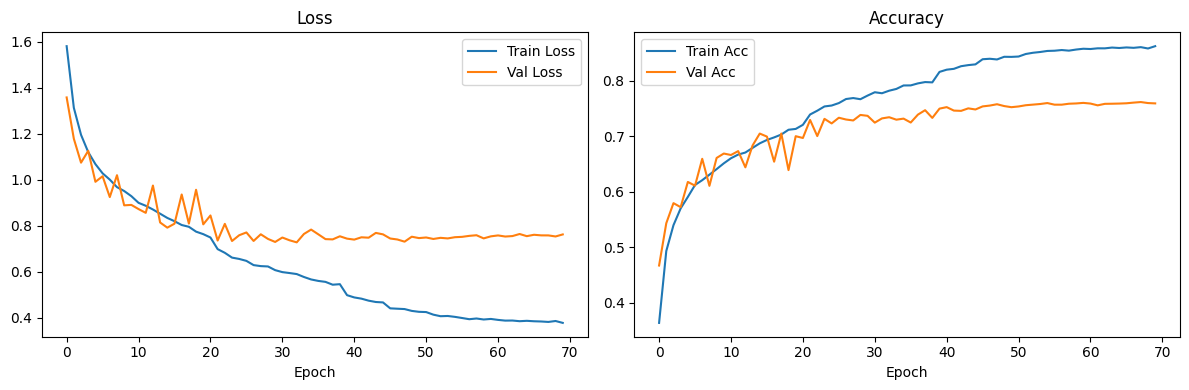

C:\Users\jakov\AppData\Local\Temp\ipykernel_3696\1744741112.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


              precision    recall  f1-score   support

       angry       0.68      0.65      0.66      1172
     disgust       0.94      0.94      0.94      1145
        fear       0.63      0.59      0.61      1151
       happy       0.87      0.90      0.89      2254
     neutral       0.67      0.74      0.70      1684
         sad       0.64      0.57      0.60      1348
    surprise       0.85      0.84      0.85      1202

    accuracy                           0.76      9956
   macro avg       0.75      0.75      0.75      9956
weighted avg       0.76      0.76      0.76      9956



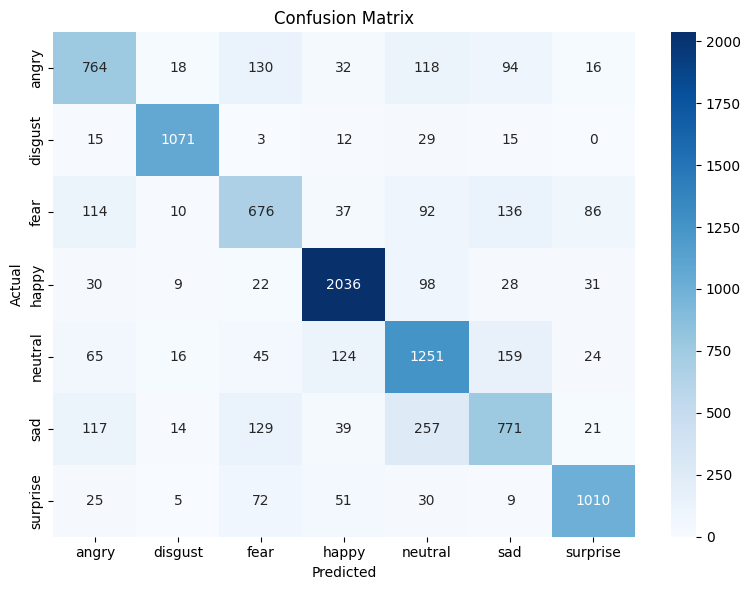

In [15]:
history = train()
plot_history(history)

checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state"])
evaluate(model, val_loader, class_names)

In [16]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def inference():
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    model.to(device)
    model.eval()
    names = checkpoint["class_names"]

    print("Webcam starting; press q to quit")
    webcam = cv2.VideoCapture(0)
    if not webcam.isOpened():
        print("Webcam error"); return

    while True:
        ret, frame = webcam.read()
        if not ret:
            break

        gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        if len(faces) == 0:
            # Fallback: classify whole frame when no face detected
            rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            tensor = val_transform(Image.fromarray(rgb)).unsqueeze(0).to(device)
            with torch.no_grad():
                probs      = torch.softmax(model(tensor), dim=1)
                conf, idx  = torch.max(probs, dim=1)
            cv2.putText(frame, f"{names[idx.item()]} {conf.item():.2f} (no face)",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        else:
            for (x, y, w, h) in faces:
                face_crop = frame[y:y+h, x:x+w]
                rgb       = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
                tensor    = val_transform(Image.fromarray(rgb)).unsqueeze(0).to(device)

                with torch.no_grad():
                    probs      = torch.softmax(model(tensor), dim=1)
                    conf, idx  = torch.max(probs, dim=1)
                    label      = names[idx.item()]

                cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
                cv2.putText(frame, f"{label} {conf.item():.2f}",
                            (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        cv2.imshow("Emotion Detector (q to quit)", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    webcam.release()
    cv2.destroyAllWindows()

In [17]:
inference()

C:\Users\jakov\AppData\Local\Temp\ipykernel_3696\4180653238.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location=device)


Webcam starting; press q to quit
Webcam error


In [ ]:
!git rm -r --cached .
!git add .
!git commit -m "Feat: Complete project"
!git push -u origin main --force